In [1]:
import sys
import os

cwd = os.getcwd()
print(cwd)
project_root = os.path.abspath(os.path.join(cwd, "../../.."))
sys.path.append(project_root)
sys.path.append(os.path.join(cwd, "XCP-explain"))

import cpmpy as cp

/Users/macbookpro/Desktop/cpmpy/cpmpy/tools/explain


/Users/macbookpro/Desktop/cpmpy/cpmpy/solvers/gurobi.py:46: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# reload cpmpy if changes made
import importlib
importlib.reload(cp)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [3]:
import numpy as np
from visualize import *
from read_data import get_data
from factory import *
from cpmpy.tools.explain import marco
from cpmpy.tools.explain.utils import diversity_matrix
from cpmpy.tools.explain.diverse_enumeration import marco_select_top_k, marco_diverse, marco_until_diverse, ocus_enum
from cpmpy.tools.explain.visualize_diversity import visualize_heatmap


# setup model

In [4]:

instance = os.path.join("XCP-explain","Benchmarks/CustomInstance.txt")
data = get_data(instance)
factory = NurseSchedulingFactory(data)
model, nurse_view = factory.get_decision_model()
cs = len(model.constraints)


## 1 MARCO

In [5]:
result = []
for i, (kind, subset) in enumerate(marco(model.constraints, solver="exact", map_solver="exact", return_mcs=False)):
    result.append(frozenset(subset))
    if i == 4:
        break

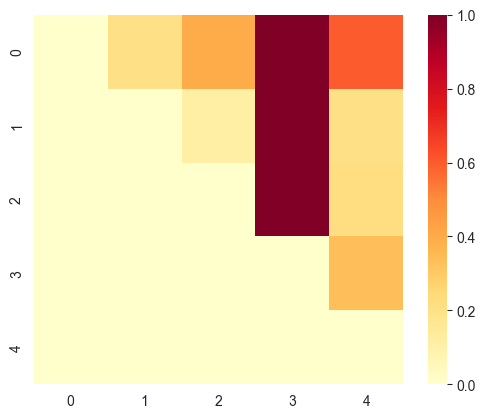

The average diversity of 5 MUSes generated by MARCO is: 0.5066666666666666


In [6]:
div_matrix = diversity_matrix(result, measure="overlap")
visualize_heatmap(div_matrix)
avg = div_matrix[np.triu_indices_from(div_matrix, k=1)].mean()
print(f"The average diversity of {len(result)} MUSes generated by MARCO is: {avg}")

In [7]:
for mus in result:
    display(visualize_constraints(mus, nurse_view, factory))

## 2 MARCO until diverse

In [16]:
top_indx, result, avg, div_matrix = marco_until_diverse(model.constraints, 5, 100)


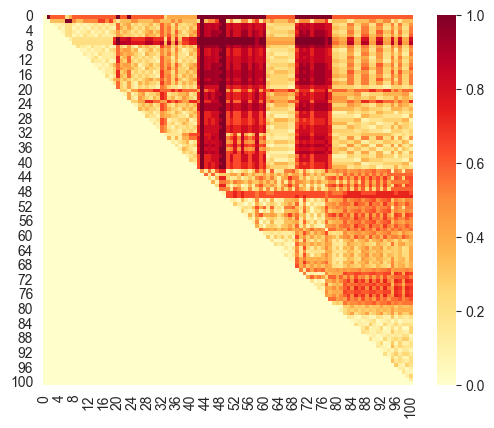

The average diversity of 5 most diverse MUSes generated by MARCO_until_diverse is: 0.8883838383838384


In [17]:
visualize_heatmap(div_matrix)
print(f"The average diversity of {len(result)} most diverse MUSes generated by MARCO_until_diverse is: {avg}")

## 3 MARCO select top k

In [18]:
top_indx, result, avg, div_matrix =  marco_select_top_k(model.constraints, 5, 20)

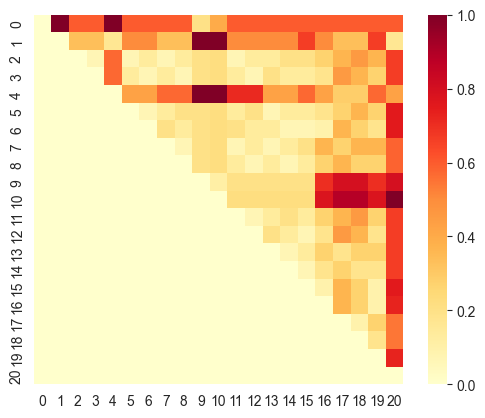

The average diversity of 5 most diverse MUSes generated by MARCO_select_top_k is: 0.7182539682539681


In [19]:
visualize_heatmap(div_matrix)
print(f"The average diversity of {len(result)} most diverse MUSes generated by MARCO_select_top_k is: {avg}")

In [20]:
for mus in result:
    display(visualize_constraints(mus, nurse_view, factory))

## 4 MARCO diverse

In [8]:
result = []
for i, (kind, subset) in enumerate(marco_diverse(model.constraints, solver="exact", map_solver="exact", return_mcs=False)):
    result.append(frozenset(subset))
    if i == 4:
        break

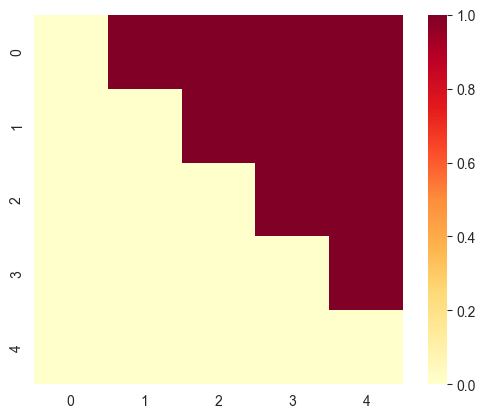

The average diversity of 5 first MUSes generated by MARCO_diverse is: 1.0


In [9]:
div_matrix = diversity_matrix(result, measure="overlap")
visualize_heatmap(div_matrix)
avg = div_matrix[np.triu_indices_from(div_matrix, k=1)].mean()
print(f"The average diversity of {len(result)} first MUSes generated by MARCO_diverse is: {avg}")

In [10]:
for mus in result:
    display(visualize_constraints(mus, nurse_view, factory))

## OCUS enumeration